<h1>Resolution parameter study</h1>

This notebook analyzes how the resolution parameter affects community detection in Venice’s public transport networks. By calculating modularity scores for different resolution values across real, rewired, and Erdős-Rényi random networks, it identifies the optimal parameter settings for revealing meaningful community structure. The results help determine which configurations best capture the modular organization of these networks.
This notebook will calculate different combinations of networks and resolution parameter values to identify the best configuration for this task.

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

n_file=["carnival_tourist","no_carnival_tourist","carnival_residents","no_carnival_residents"]
n_folder='../models/'

### Rewiring algorithm

The rewiring algorithm creates a random version of the original network by keeping the same set of nodes and redistributing the existing edge weights among randomly selected node pairs. This preserves the number of edges and the weight distribution, but randomizes the connections, allowing comparison of structural properties with the original network

### Erdos Renyi algorihtm

The Erdős-Rényi model generates random graphs by connecting pairs of nodes with edges chosen uniformly at random. In its simplest form, each possible edge between nodes is included with a fixed probability, or a fixed number of edges is distributed randomly among all possible node pairs. This produces networks with no inherent structure, serving as a baseline for comparison with real-world networks.

In [13]:
import sys
sys.path.append('../bin')

import random_networks as rn

<h2>Venice networks </h2>

Calculation of the modularity of the communities obtained by Louvain depending on the value of the resolution parameter.

In [24]:
resolutions = np.linspace(0.5, 2.0, 16)
dict_mod=dict()

for i in n_file:
    G=nx.read_graphml(n_folder+i+'.graphml')
    dict_mod[i]=list()
    for j in resolutions:
        cm=nx.community.louvain_communities(G,resolution=j)
        modularity = nx.community.modularity(G,cm)

        dict_mod[i].append(modularity)

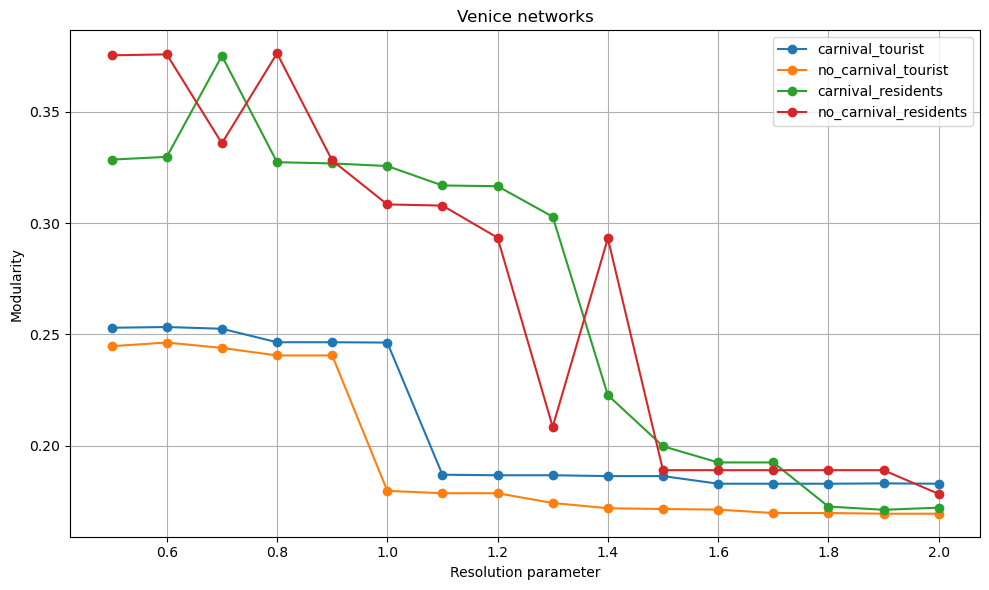

In [25]:
x = resolutions
# Create graph
plt.figure(figsize=(10, 6))

# Draw each line
for label, values in dict_mod.items():
    plt.plot(x, values, marker='o', label=label)

# Add labels and captions
plt.title('Venice networks')
plt.xlabel('Resolution parameter')
plt.ylabel('Modularity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<h2>Rewiring networks </h2>

Calculation of the modularity of the communities obtained by Louvain depending on the value of the resolution parameter.

In [26]:
resolutions = np.linspace(0.5, 2.0, 16)
dict_mod=dict()


for i in n_file:
    G=rn.rewiring(nx.read_graphml(n_folder+i+'.graphml'))
    dict_mod[i]=list()
    for j in resolutions:
        cm=nx.community.louvain_communities(G,resolution=j)
        modularity = nx.community.modularity(G,cm)

        dict_mod[i].append(modularity)


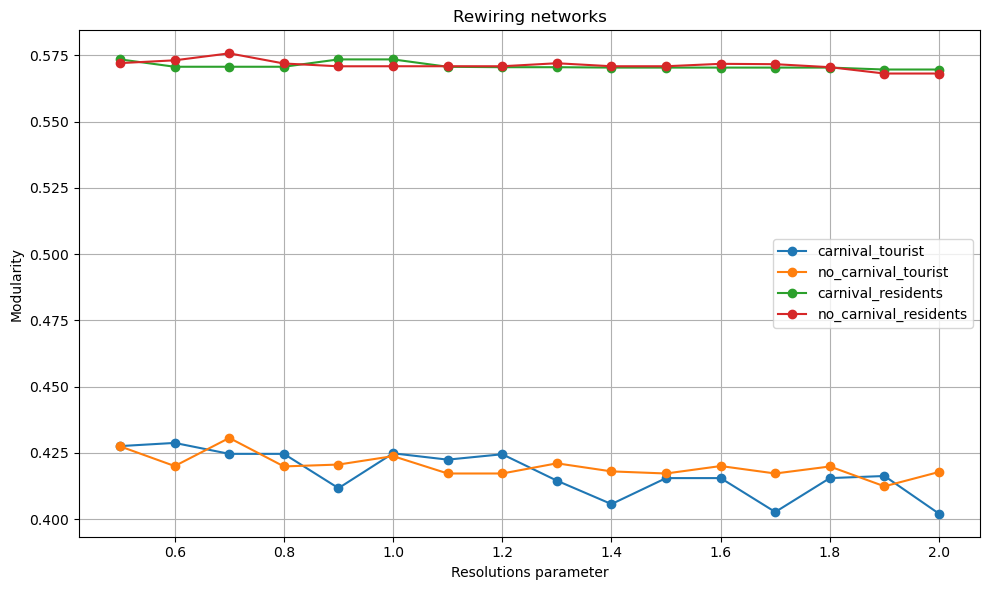

In [27]:
x = resolutions
# Create graph
plt.figure(figsize=(10, 6))

# Drawing each line
for label, values in dict_mod.items():
    plt.plot(x, values, marker='o', label=label)

# Add labels and captions
plt.title('Rewiring networks')
plt.xlabel('Resolutions parameter')
plt.ylabel('Modularity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<h2>Erdős-Rényi networks </h2>

Calculation of the modularity of the communities obtained by Louvain depending on the value of the resolution parameter.
In the case of the model under consideration, the generated network displays a configuration with an equal number of nodes, while the link weights fluctuate within the range of the maximum and minimum value corresponding to each of the networks.

In [28]:
resolutions = np.linspace(0.5, 2.0, 16)
dict_mod=dict()


for i in n_file:
    G=nx.read_graphml(n_folder+i+'.graphml')
    pesos = [d['weight'] for u, v, d in G.edges(data=True) if 'weight' in d]

    # Obtain minimum and maximum
    peso_min = min(pesos)
    peso_max = max(pesos)
    G=rn.erdos_renyi_weighted_same_nodes(G, weight_range=(peso_min, peso_max), directed=True, seed=None)
    
    dict_mod[i]=list()
    for j in resolutions:
        cm=nx.community.louvain_communities(G,resolution=j)
        modularity = nx.community.modularity(G,cm)

        dict_mod[i].append(modularity)


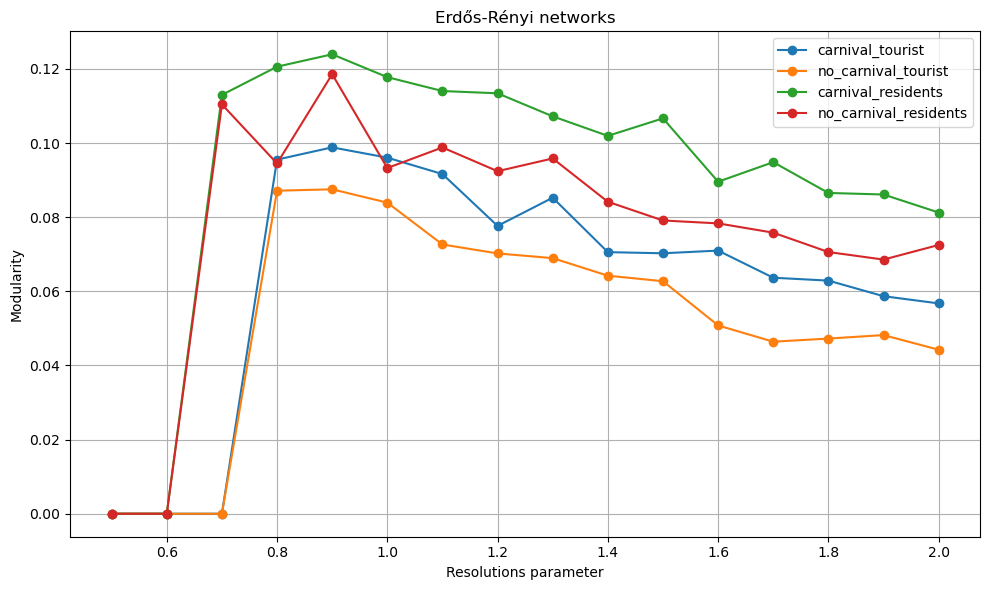

In [29]:
x = resolutions
# Create graph
plt.figure(figsize=(10, 6))

# Drawing each line
for label, values in dict_mod.items():
    plt.plot(x, values, marker='o', label=label)

# Add labels and captions
plt.title('Erdős-Rényi networks')
plt.xlabel('Resolutions parameter')
plt.ylabel('Modularity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<h1>Conclusion</h1>

An analysis of the data reveals that, in nearly all graphs, the optimal value is 1. It is evident that lower values result in suboptimal outcomes when assessing modularity. Higher values do not yield superior results. Moreover, in instances where 1 is not the optimal value, there are no substantial differences.